### FFT Example from SciPy:
https://docs.scipy.org/doc/scipy/reference/tutorial/fft.html

In [1]:
#import packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.fftpack
import scipy.fft
import os
import csv
import re
import glob
import matplotlib.patches as patches

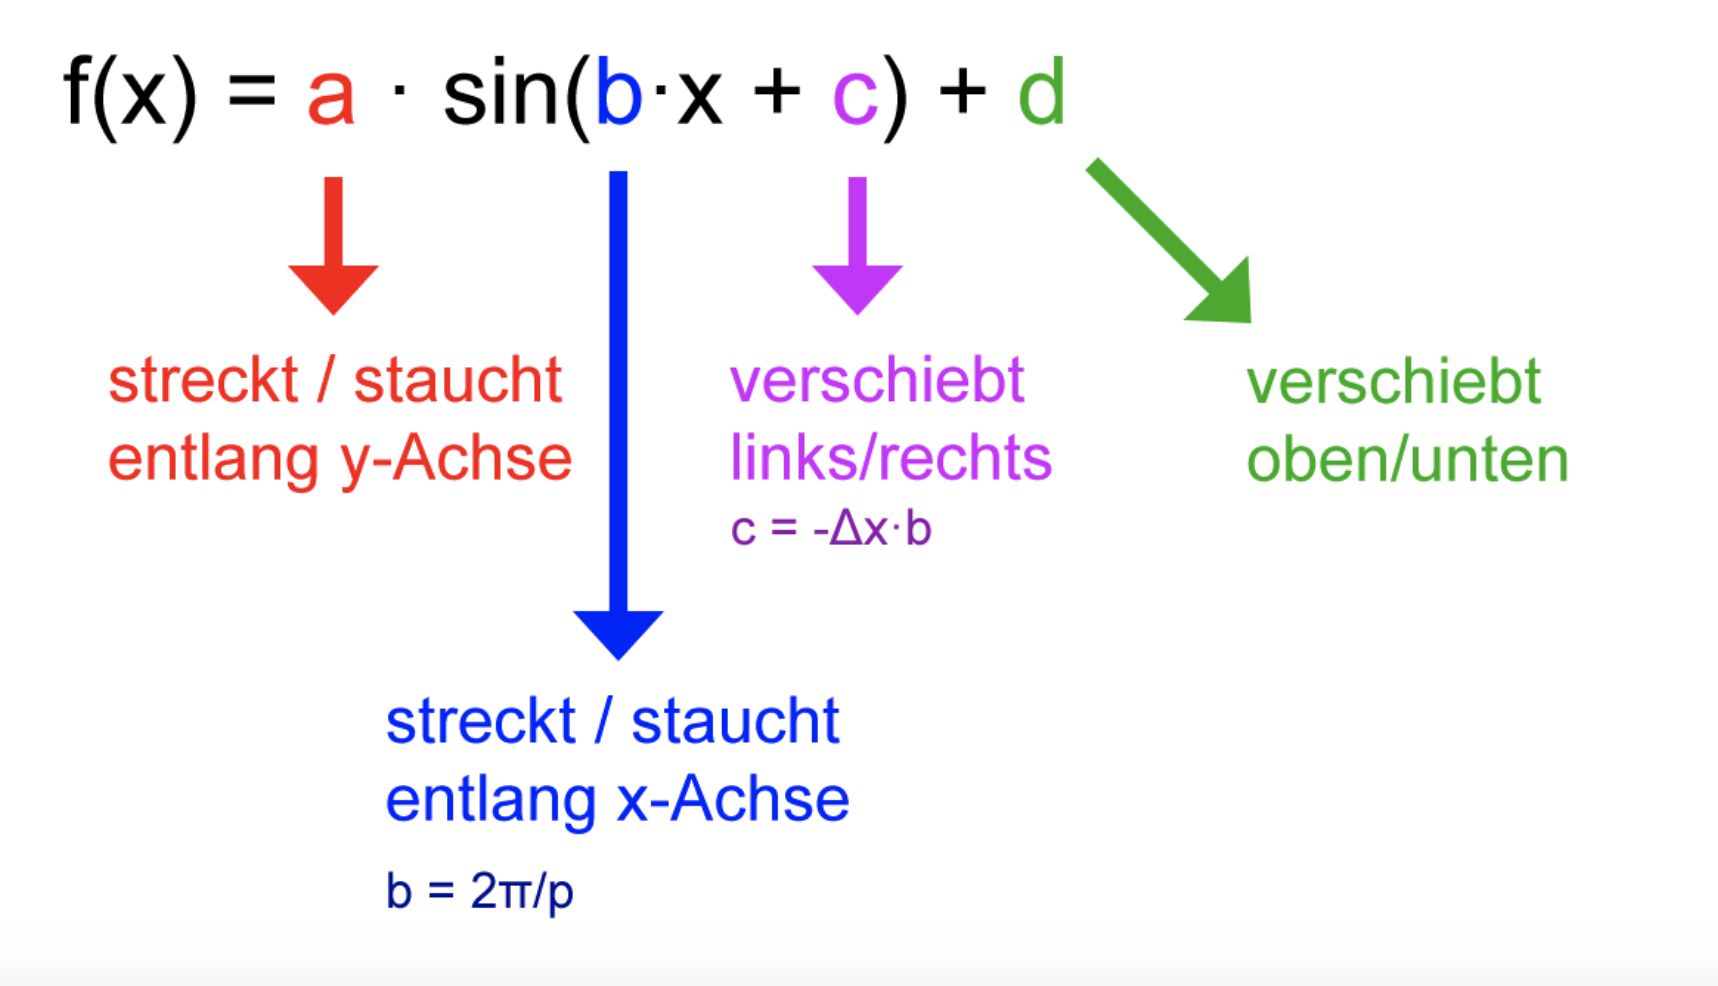

In [2]:
from coordinate_conversion_functions import *

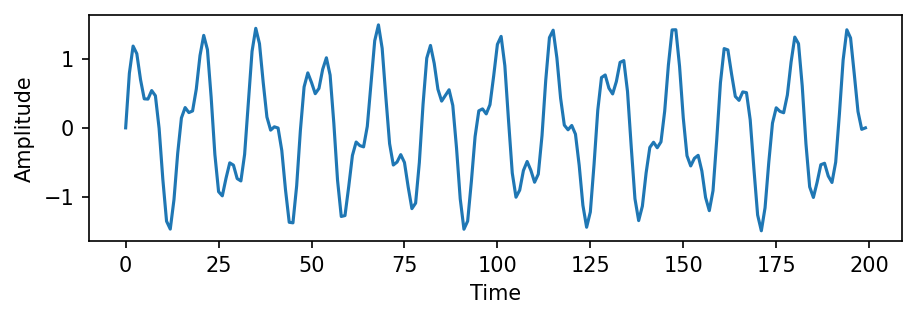

In [3]:
#this is the intial funciton constructed out of 2 sinoid functions y1 and y2 (see below)
N = 200 #number of samplepoints
# sample spacing
T = 1.0 / 800.0
x = np.linspace(0.0, N*T, N) #array from 0 to 0.25 with 200 values
y = np.sin(50.0 * 2*np.pi*x) + 0.5*np.sin(120.0 * 2.0*np.pi*x)

plt.figure(figsize=(7,2), dpi=150)
plt.plot(y)
plt.ylabel('Amplitude')
plt.xlabel('Time')
plt.show()

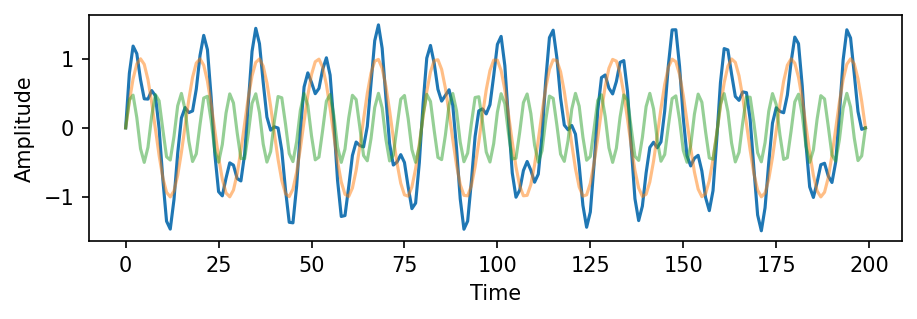

In [6]:
#composite and consitutive functions
y1= np.sin(50.0 * 2.0*np.pi*x)
y2= 0.5*np.sin(120.0 * 2.0*np.pi*x)
plt.figure(figsize=(7,2), dpi=150)
plt.plot(y)
plt.plot(y1, alpha=0.5)
plt.plot(y2, alpha=0.5)
plt.ylabel('Amplitude')
plt.xlabel('Time')
plt.show()

In [7]:
min(y2)

-0.49998442344707805

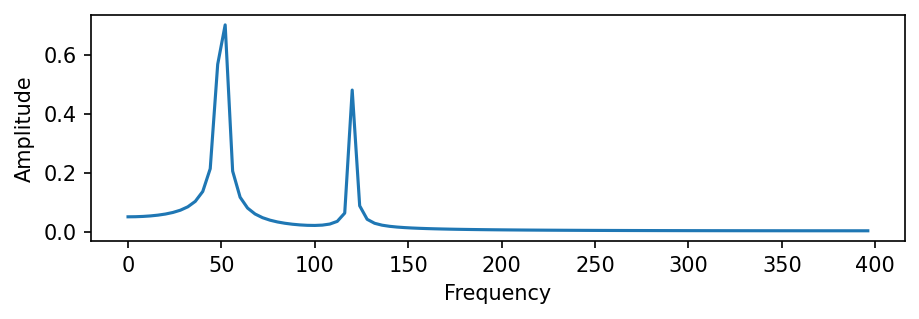

In [7]:
#here the fft does its magic
yf = scipy.fftpack.fft(y)
xf = scipy.fftpack.fftfreq(N, T)[:N//2]
fig, ax = plt.subplots(figsize=(7,2), dpi=150)
ax.plot(xf, 2.0/N * np.abs(yf[:N//2]))
plt.ylabel('Amplitude')
plt.xlabel('Frequency')
plt.show()

# FFT for all curvatures

In [6]:
#load data
#csv_filepath='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_14-41-11_chemotaxisl_worm2_spline_K.csv'
csv_filepath='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_17-01-27_chemotaxis_worm6_spline_K.csv'
K = np.genfromtxt(csv_filepath, delimiter=',')
#to remove nan rows in the data
K=K[~np.isnan(K).any(axis=1)]
Kt=K.T

In [5]:
#generate Fourier spectrum map
def fourier_map(csv_fft):
    # output_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_fourier'
    # csv_filepath=os.path.join(output_path,'2020-07-01_14-41-11_chemotaxisl_worm2_fourierMap.csv')
    df=pd.read_csv(csv_fft, header=None)
    #plotting
    fig, ax = plt.subplots(figsize=(10,3))
    ax.imshow(df.iloc[:,0:519], extent=[0,xf[519],100,0], vmin=0, vmax=0.0025, aspect=0.2)#aspect=0.0025)#, cmap='Reds')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Body Segment')
    plt.title(re.split('/',csv_fft)[-1])
    #plt.savefig(re.split('.csv',csv_fft)[0]+'2.tiff',dpi=600)
    plt.show()

In [10]:
#as a function

#generate Fourier csv file
def fourier_transform(csv_skeleton, output_path):
    filename=re.split('/',csv_skeleton)[-1][:-16]
    print(filename)
    K = np.genfromtxt(csv_skeleton, delimiter=',')
    #to remove nan rows in the data
    K=K[~np.isnan(K).any(axis=1)]
    Kt=K.T
    plt.rcParams.update({'figure.max_open_warning': 0})
    #number of sample points
    #Kts= Kt short
    Kts=Kt#[:,79640:130700]

    N=Kts.shape[1]
    #hanning
    hann=np.hanning(N)
    #sample spacing
    T=1.0/167.0
    x=np.linspace(0.0, N*T, N)
    xf=np.linspace(0.0, 1.0//(2.0*T), N//2)
    #xf=scipy.fftpack.fftfreq(N,T)

    fourierMap=open(os.path.join(output_path,filename)+'FourierTransform.csv','w', newline='')
    csv_writerfourierMap=csv.writer(fourierMap)

    for idx, segment in enumerate(Kts):
        #if idx%5!=0:continue
        y=segment
        yf=scipy.fftpack.fft(y)#*hann)
        #y axis
        y_axis=2.0/N * np.abs(yf[1:N//2])

        #writer:
        csv_writerfourierMap.writerow(y_axis)
        #plotting:
        plotting=0
        if plotting==0:continue
        plt.figure(figsize=(15,3))
        plt.subplot(1,3,1)
        plt.plot(y)
        plt.title('Signal at segment '+str(idx))
        plt.xlabel('Time (frames)')
        plt.ylabel('Signal Amplitude (a.u)')

        plt.subplot(1,3,2)
        plt.plot(1/xf[1:N//2], y_axis)
        plt.xlim(0,10)
        plt.title('Signal Period at segment '+str(idx))
        plt.xlabel('Period (s)')
        plt.ylabel('Signal Amplitude (a.u)')

        plt.subplot(1,3,3)
        plt.plot(xf[1:N//2], y_axis)
        plt.xlim(0,max(xf[1:N//2]))
        plt.xlim(0,2)
        plt.title('Signal Frequency at segment '+str(idx))
        plt.ylabel('Signal Amplitude (a.u)')
        plt.xlabel('Frequency (Hz)')

        plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.25, hspace=0.25)

    fourierMap.close()


In [44]:
#fourier transform
output_path='/groups/zimmer/shared_projects/DanielMitic/data/ulises_chemotaxis/fourier/all_fourier_good/'
path = '/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/*spline_K.csv'
for fname in glob.glob(path):
    #print (fname)
    #fourier_transform(fname,output_path)

2020-06-30_16-25-56_chemotaxis_wo
2020-06-30_17-47-20_chemotaxis_wo
2020-06-30_16-54-43_chemotaxis_wo
2020-07-01_14-41-11_chemotaxisl_wo
2020-07-01_13-21-00_chemotaxisl_wo
2020-07-01_10-50-18_control_wo
2020-07-01_15-42-06_chemotaxisl_wo
2020-06-30_18-17-47_chemotaxis_wo
2020-07-01_15-13-35_chemotaxisl_wo
2020-07-01_11-50-53_control_wo
2020-07-01_10-10-48_control_wo
2020-06-30_15-48-51_chemotaxis_wo
2020-07-01_16-20-36_chemotaxisl_wo
2020-07-01_17-32-12_control_wo
2020-07-01_17-58-13_control_wo
2020-07-01_17-01-27_chemotaxis_wo
2020-07-01_18-36-25_control_wo


In [ ]:
#fouriermap colorcode shows the amplitude
path = '/groups/zimmer/shared_projects/DanielMitic/data/ulises_chemotaxis/fourier/all_fourier_good/*.csv'
for fname in glob.glob(path):
    print (fname)
    fourier_map(fname)

# fourier for parts of tracks of single worms

In [4]:
#these are csvs i created with the head_position script 
path='/groups/zimmer/shared_projects/DanielMitic/data/ulises_chemotaxis/head_tail_center_absolute_coordinates_x_ref_corrected/2020-07-01_14-41-11_chemotaxisl_worm2-TablePosRecord.csv'
df_head_tail_center_coords=pd.read_csv(path)
df_head_tail_center_coords

,Unnamed: 0,time,xc,x_center,yc,y_center,x_head_corrected,y_head_corrected,x_tail_corrected,y_tail_corrected
0,0,14:41:11.143,x,15.4866,y,15.1372,14.962800,15.022802,16.040837,15.092046
1,1,14:41:13.030,x,15.3373,y,15.1046,14.810655,14.990773,15.887005,15.059743
2,2,14:41:13.030,x,15.3373,y,15.1046,14.810535,14.992948,15.887005,15.060383
3,3,14:41:13.030,x,15.3373,y,15.1046,14.810414,14.993450,15.887005,15.060505
4,4,14:41:13.045,x,15.3372,y,15.1046,14.810314,14.995230,15.886905,15.060579
...,...,...,...,...,...,...,...,...,...,...
199996,199996,15:01:13.037,x,-0.0166,y,25.6222,-0.216802,26.147656,0.091517,25.106452
199997,199997,15:01:13.037,x,-0.0166,y,25.6223,-0.216802,26.147756,0.091581,25.106552
199998,199998,15:01:13.037,x,-0.0166,y,25.6224,-0.216802,26.147856,0.091646,25.106535
199999,199999,15:01:13.054,x,-0.0167,y,25.6224,-0.216842,26.147410,0.091546,25.106166


        Unnamed: 0          time  xc  x_center  yc  y_center  \
200000      200000  15:01:13.054   x   -0.0167   y   25.6224   

        x_head_corrected  y_head_corrected  x_tail_corrected  y_tail_corrected  
200000         -0.216298          26.14741          0.091606         25.105324  


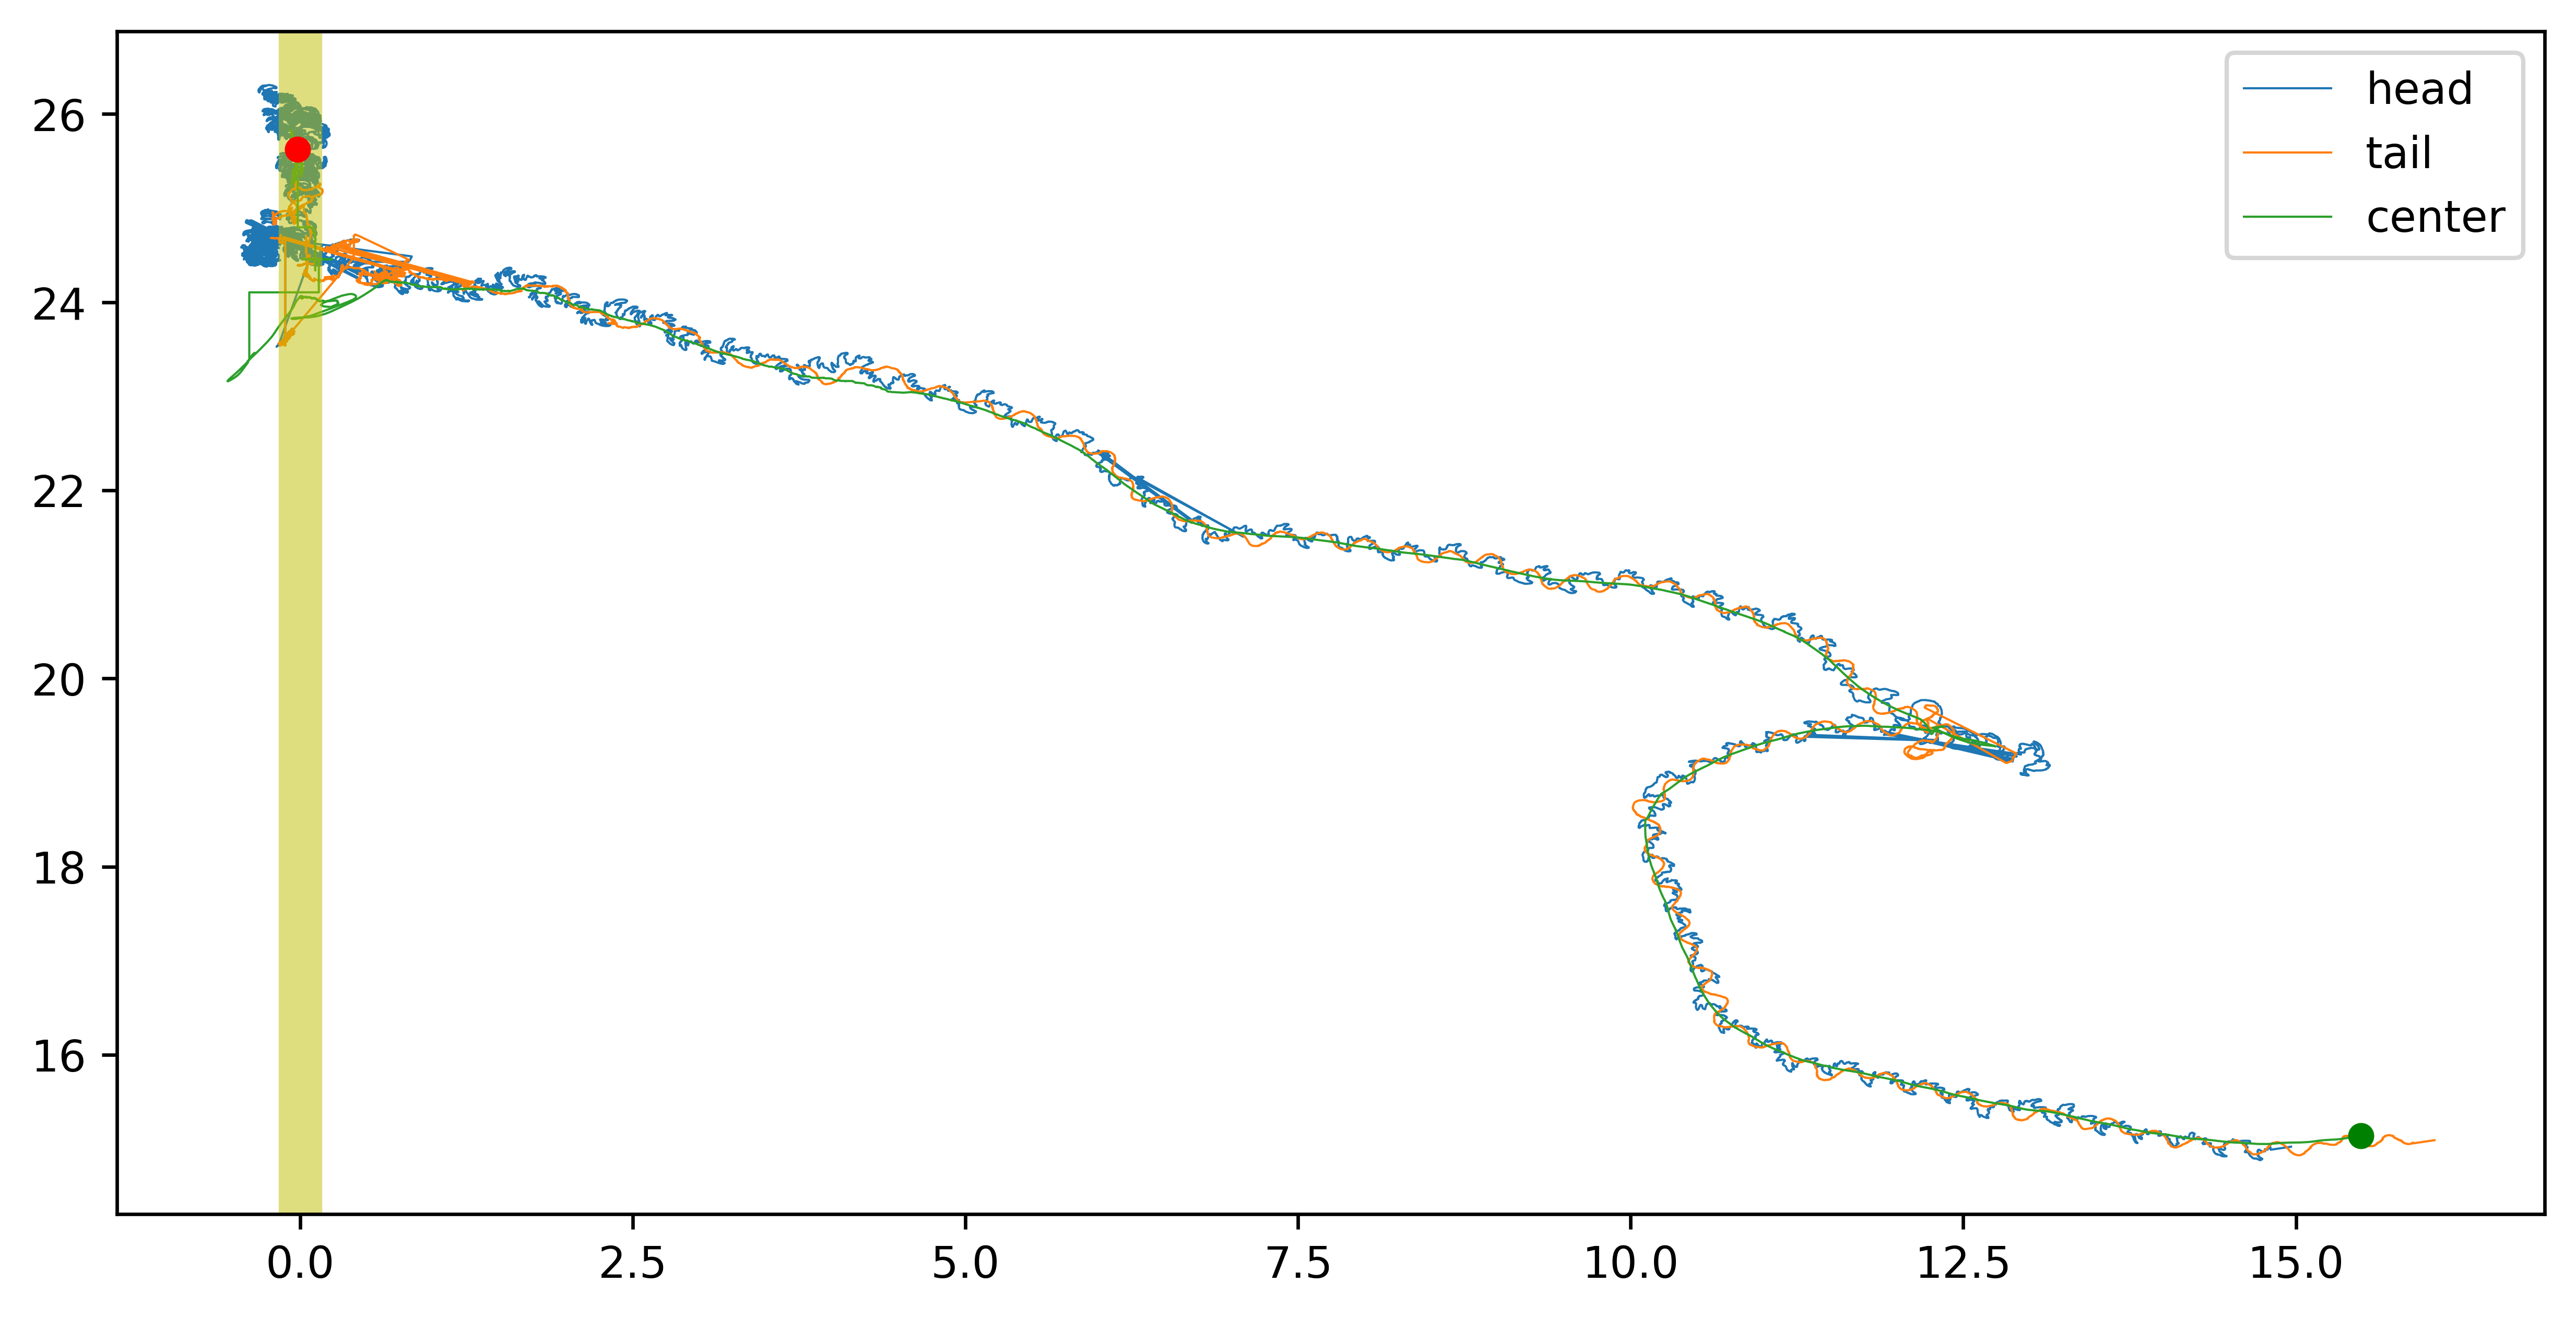

In [5]:
#plot the track to determine on which parts in want to do the fourier transformations
figsize_x=10
figsize_y=5
line_width=0.5
x_head_corrected=df_head_tail_center_coords['x_head_corrected']
y_head_corrected=df_head_tail_center_coords['y_head_corrected']
x_tail_corrected=df_head_tail_center_coords['x_tail_corrected']
y_tail_corrected=df_head_tail_center_coords['y_tail_corrected']
x_center_pos=df_head_tail_center_coords['x_center']
y_center_pos=df_head_tail_center_coords['y_center']
print(df_head_tail_center_coords.tail(1))
fig3, ax3 = plt.subplots(1,1, figsize = (figsize_x,figsize_y), dpi=600)
ax3.plot(x_head_corrected,y_head_corrected,label="head",linewidth=line_width)
ax3.plot(x_tail_corrected,y_tail_corrected,label="tail",linewidth=line_width)
ax3.plot(x_center_pos,y_center_pos,label="center",linewidth=line_width)
ax3.axvline(x=0, ymin=0, ymax=1, lw=10, alpha=.5, color='y')
ax3.plot(df_head_tail_center_coords['x_center'][0],df_head_tail_center_coords['y_center'][0], 'go', markersize=5)
ax3.plot(df_head_tail_center_coords['x_center'].tail(1),df_head_tail_center_coords['y_center'].tail(1), 'ro', markersize=5)
ax3.legend()
  


In [52]:
#here i pull out timeframes where the worm is either awy form food chemotaxing or in the food, in order to compare 
#it with fourier transformation
away_from_food=df_head_tail_center_coords[(df_head_tail_center_coords['x_head_corrected'].between(11, 14)) & 
(df_head_tail_center_coords['y_head_corrected']< 18)]
                    
xmin=away_from_food['x_head_corrected'].min()
xmax=away_from_food['x_head_corrected'].max()
ymin=away_from_food['y_head_corrected'].min()
ymax=away_from_food['y_head_corrected'].max()

      Unnamed: 0          time  xc  x_center  yc  y_center  x_head_corrected  \
1696        1696  14:41:23.193   x   14.4887   y   15.0726         13.999205   
1697        1697  14:41:23.193   x   14.4881   y   15.0727         13.996597   
1698        1698  14:41:23.209   x   14.4874   y   15.0728         13.994600   
1699        1699  14:41:23.209   x   14.4867   y   15.0729         13.992257   
1700        1700  14:41:23.225   x   14.4861   y   15.0730         13.989861   
...          ...           ...  ..       ...  ..       ...               ...   
9600        9600  14:42:10.615   x   11.4097   y   15.9003         11.001833   
9601        9601  14:42:10.631   x   11.4095   y   15.9004         11.001516   
9602        9602  14:42:10.631   x   11.4091   y   15.9006         11.001116   
9603        9603  14:42:10.631   x   11.4088   y   15.9007         11.000748   
9604        9604  14:42:10.647   x   11.4084   y   15.9008         11.000335   

      y_head_corrected  x_tail_correcte

In [55]:
away_from_food.describe()

,Unnamed: 0,x_center,y_center,x_head_corrected,y_head_corrected,x_tail_corrected,y_tail_corrected
count,7909.000000,7909.000000,7909.000000,7909.000000,7909.000000,7909.000000,7909.000000
mean,5650.000000,12.968675,15.442587,12.516967,15.561781,13.497662,15.284296
std,2283.275973,0.867742,0.242911,0.861283,0.271560,0.875883,0.226852
min,1696.000000,11.408400,15.072600,11.000335,15.061343,11.967529,14.932167
25%,3673.000000,12.229800,15.230100,11.764243,15.336766,12.766795,15.072044
50%,5650.000000,13.015700,15.411300,12.568792,15.517497,13.533974,15.268369
75%,7627.000000,13.693100,15.648400,13.238935,15.794796,14.257452,15.459278
max,9604.000000,14.488700,15.900800,13.999205,16.162679,15.018303,15.774752


        Unnamed: 0          time  xc  x_center  yc  y_center  \
200000      200000  15:01:13.054   x   -0.0167   y   25.6224   

        x_head_corrected  y_head_corrected  x_tail_corrected  y_tail_corrected  
200000         -0.216298          26.14741          0.091606         25.105324  


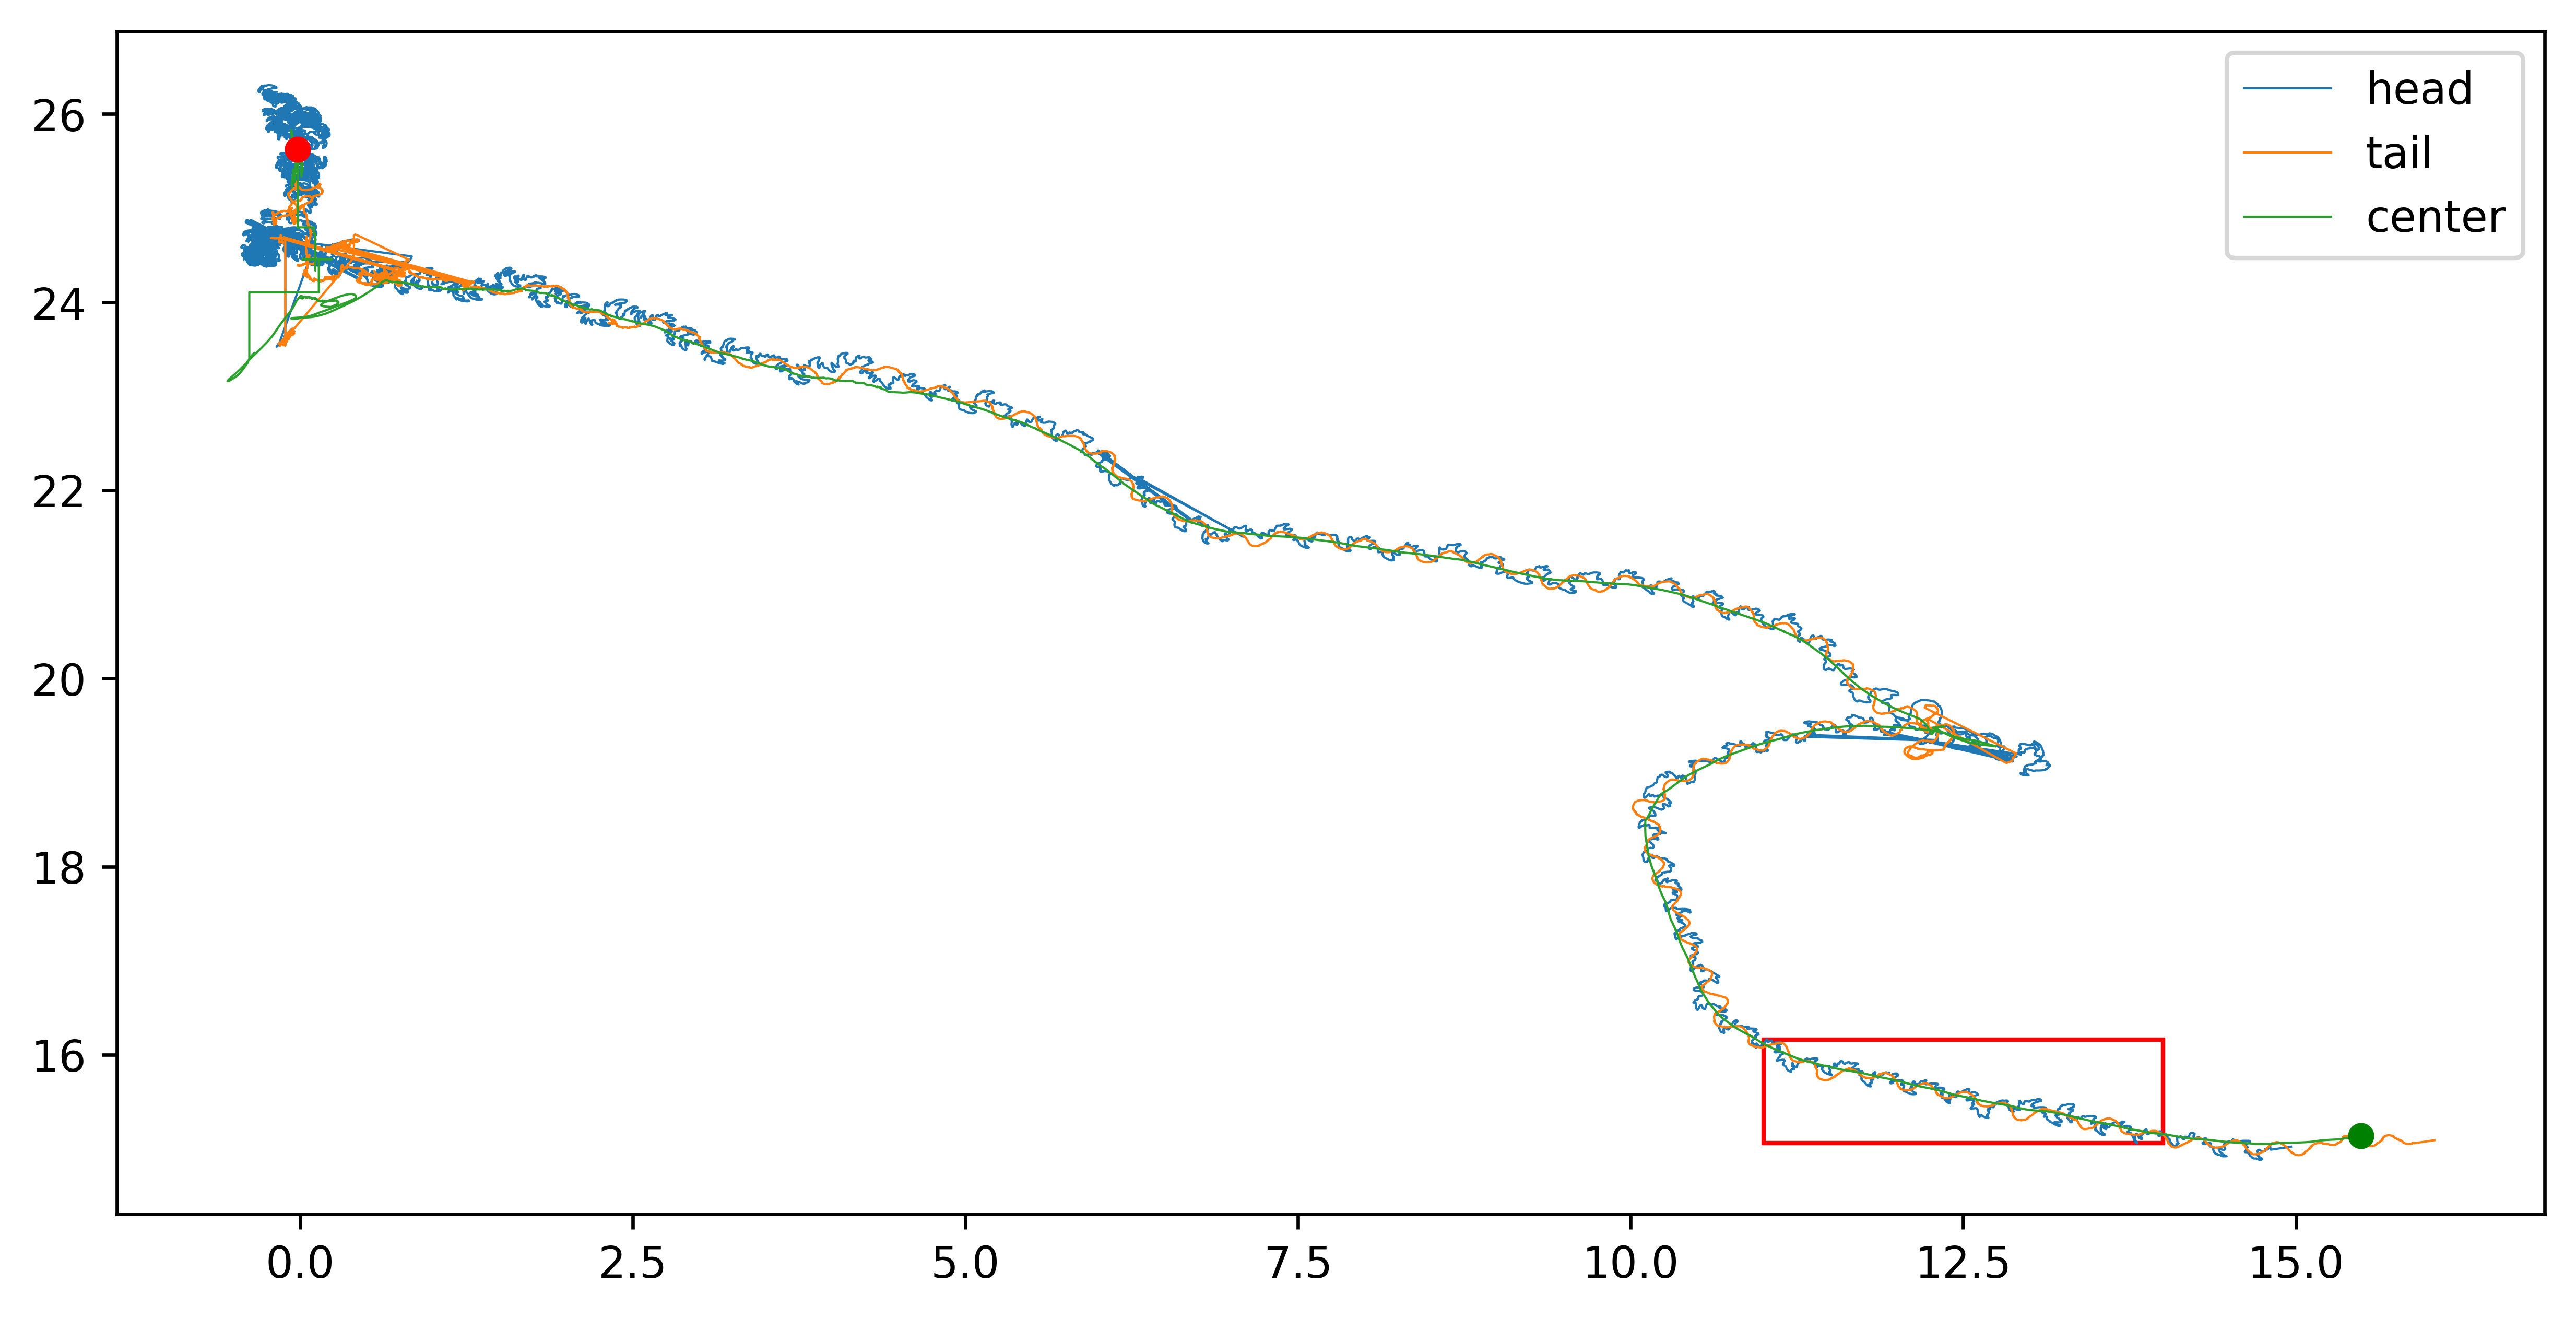

In [53]:
#plot the track to determine on which parts in want to do the fourier transformations
figsize_x=10
figsize_y=5
line_width=0.5
x_head_corrected=df_head_tail_center_coords['x_head_corrected']
y_head_corrected=df_head_tail_center_coords['y_head_corrected']
x_tail_corrected=df_head_tail_center_coords['x_tail_corrected']
y_tail_corrected=df_head_tail_center_coords['y_tail_corrected']
x_center_pos=df_head_tail_center_coords['x_center']
y_center_pos=df_head_tail_center_coords['y_center']
print(df_head_tail_center_coords.tail(1))
fig3, ax3 = plt.subplots(1,1, figsize = (figsize_x,figsize_y), dpi=600)
ax3.plot(x_head_corrected,y_head_corrected,label="head",linewidth=line_width)
ax3.plot(x_tail_corrected,y_tail_corrected,label="tail",linewidth=line_width)
ax3.plot(x_center_pos,y_center_pos,label="center",linewidth=line_width)
ax3.plot(df_head_tail_center_coords['x_center'][0],df_head_tail_center_coords['y_center'][0], 'go', markersize=5)
ax3.plot(df_head_tail_center_coords['x_center'].tail(1),df_head_tail_center_coords['y_center'].tail(1), 'ro', markersize=5)
xposition = [away_from_food['x_head_corrected'].min(), away_from_food['x_head_corrected'].max()]
#for xc in xposition:
   # plt.axvline(x=xc, color='k', linestyle='--')

rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, linewidth=1, edgecolor='r', facecolor='none')
ax3.add_patch(rect)

ax3.legend()

In [3]:
#as a function

#generate Fourier csv file
def fourier_transform(csv_skeleton, output_path):
    filename=re.split('/',csv_skeleton)[-1][:-16]
    print(filename)
    K = np.genfromtxt(csv_skeleton, delimiter=',')
    #to remove nan rows in the data
    K=K[~np.isnan(K).any(axis=1)]
    Kt=K.T
    plt.rcParams.update({'figure.max_open_warning': 0})
    #number of sample points
    #Kts= Kt short
    Kts=Kt[:,1696:9604]

    N=Kts.shape[1]
    #hanning
    hann=np.hanning(N)
    #sample spacing
    T=1.0/167.0
    x=np.linspace(0.0, N*T, N)
    xf=np.linspace(0.0, 1.0//(2.0*T), N//2)
    #xf=scipy.fftpack.fftfreq(N,T)

    fourierMap=open(os.path.join(output_path,filename)+'FourierTransform.csv','w', newline='')
    csv_writerfourierMap=csv.writer(fourierMap)

    for idx, segment in enumerate(Kts):
        #if idx%5!=0:continue
        y=segment
        yf=scipy.fftpack.fft(y)#*hann)
        #y axis
        y_axis=2.0/N * np.abs(yf[1:N//2])

        #writer:
        csv_writerfourierMap.writerow(y_axis)
        #plotting:
        plotting=0
        if plotting==0:continue
        plt.figure(figsize=(15,3))
        plt.subplot(1,3,1)
        plt.plot(y)
        plt.title('Signal at segment '+str(idx))
        plt.xlabel('Time (frames)')
        plt.ylabel('Signal Amplitude (a.u)')

        plt.subplot(1,3,2)
        plt.plot(1/xf[1:N//2], y_axis)
        plt.xlim(0,10)
        plt.title('Signal Period at segment '+str(idx))
        plt.xlabel('Period (s)')
        plt.ylabel('Signal Amplitude (a.u)')

        plt.subplot(1,3,3)
        plt.plot(xf[1:N//2], y_axis)
        plt.xlim(0,max(xf[1:N//2]))
        plt.xlim(0,2)
        plt.title('Signal Frequency at segment '+str(idx))
        plt.ylabel('Signal Amplitude (a.u)')
        plt.xlabel('Frequency (Hz)')

        plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.25, hspace=0.25)

    fourierMap.close()


In [4]:
#creates Fourier csv file
path='/groups/zimmer/shared_projects/DanielMitic/data/ulises_chemotaxis/fourier/all_fourier/'
csv_skeleton='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_14-41-11_chemotaxisl_worm2_spline_K.csv'
fourier_transform(csv_skeleton, path)

2020-07-01_14-41-11_chemotaxisl_wo


In [7]:
#these are the fourier transformed data
path='/groups/zimmer/shared_projects/DanielMitic/data/ulises_chemotaxis/fourier/all_fourier/2020-07-01_14-41-11_chemotaxisl_woFourierTransform.csv'
df=pd.read_csv(path)

In [8]:
#load data contains the curvature for each of 100 segments at each timepoint
csv_filepath='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_14-41-11_chemotaxisl_worm2_spline_K.csv'
K = np.genfromtxt(csv_filepath, delimiter=',')
#to remove nan rows in the data
K=K[~np.isnan(K).any(axis=1)]
Kt=K.T
Kts=Kt[:,1696:9604]
N=Kts.shape[1]
#sample spacing
T=1.0/167.0
x=np.linspace(0.0, N*T, N)
xf=np.linspace(0.0, 1.0//(2.0*T), N//2)

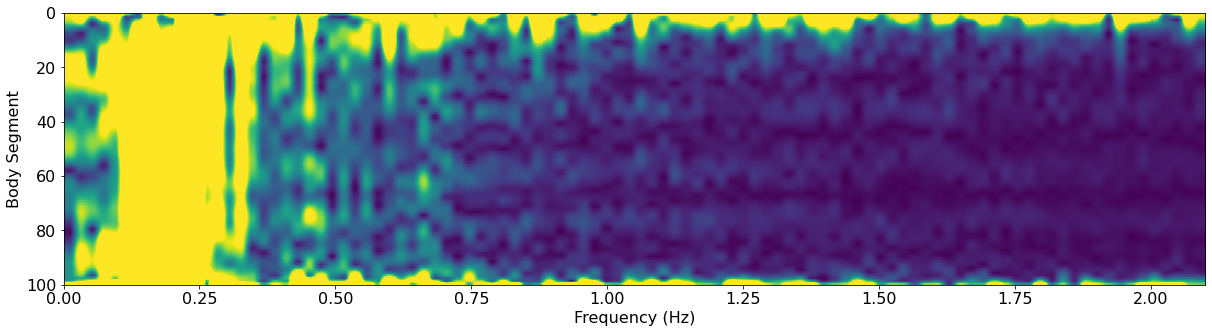

In [22]:
#generate Fourier spectrum map
fig, ax = plt.subplots(figsize=(50,5))
ax.imshow(df.iloc[:,0:100], extent=[0,xf[100],100,0], vmin=0, vmax=0.0025, aspect=0.005)#aspect=0.0025)#, cmap='Reds')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Body Segment')
#plt.title(re.split('/',csv_fft)[-1])
#plt.savefig(re.split('.csv',csv_fft)[0]+'2.tiff',dpi=600)
plt.show()

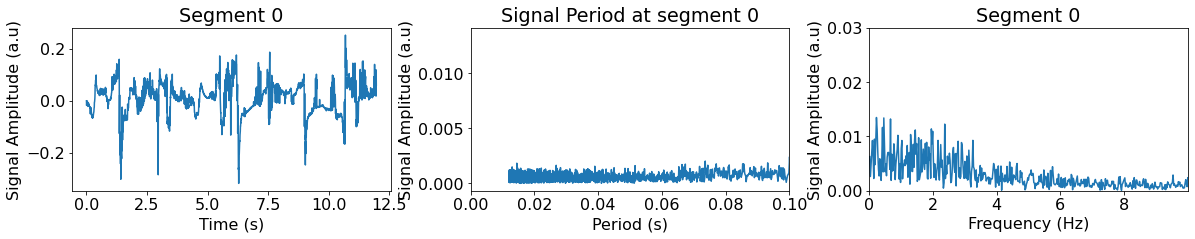

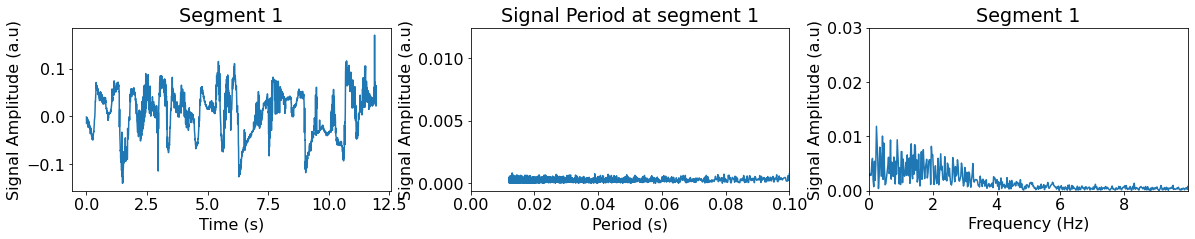

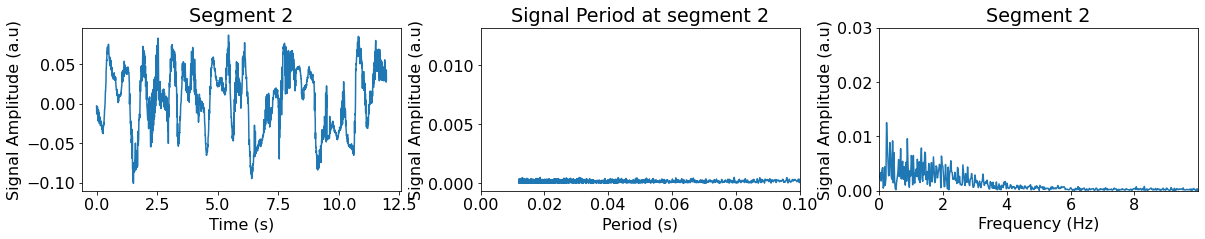

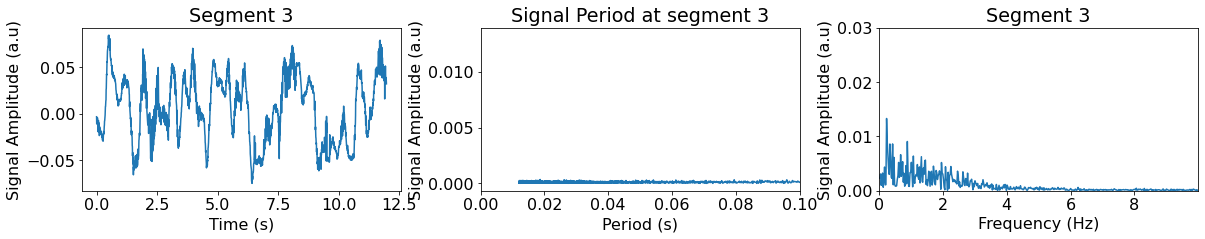

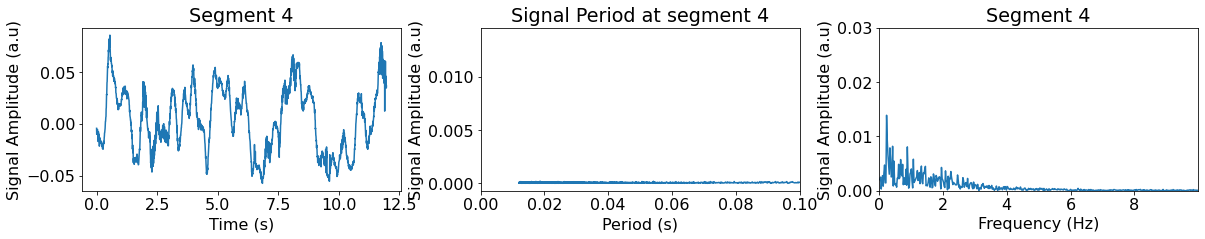

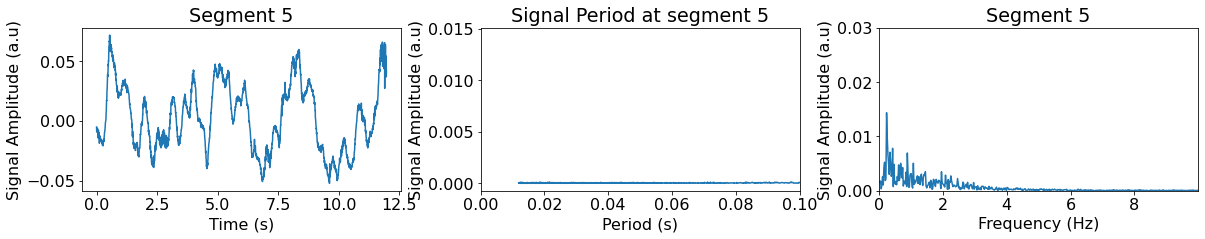

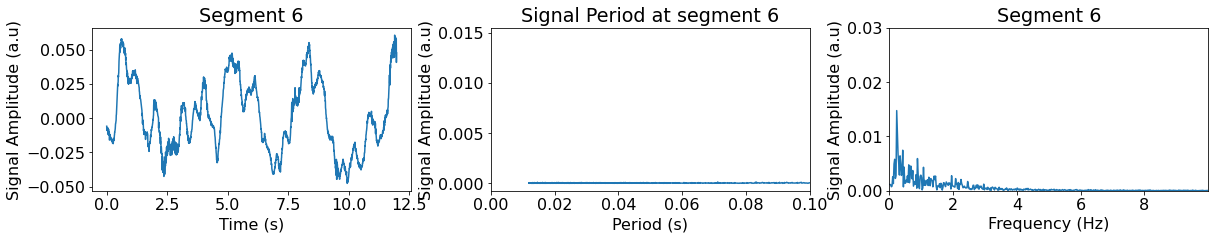

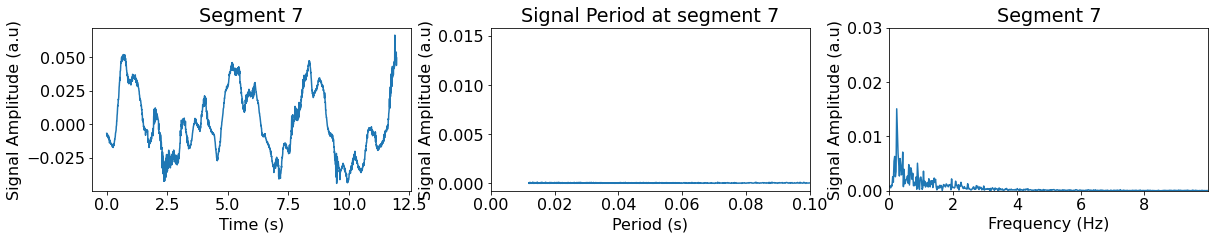

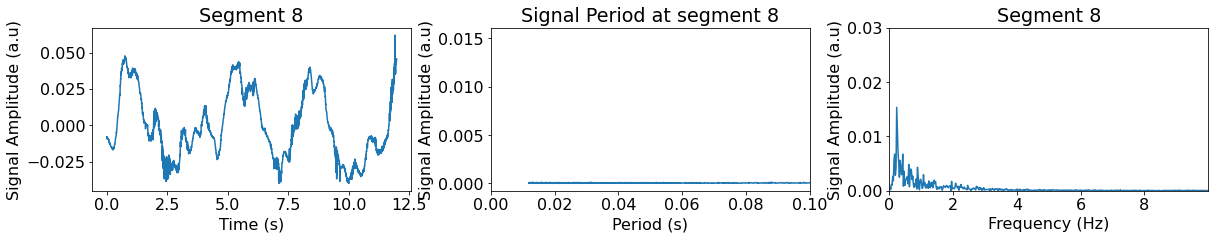

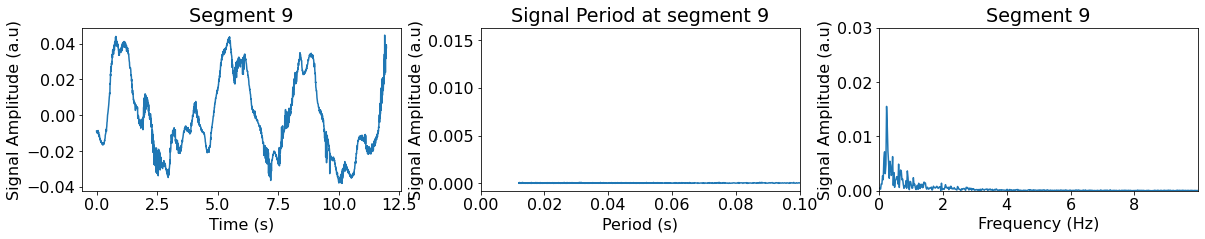

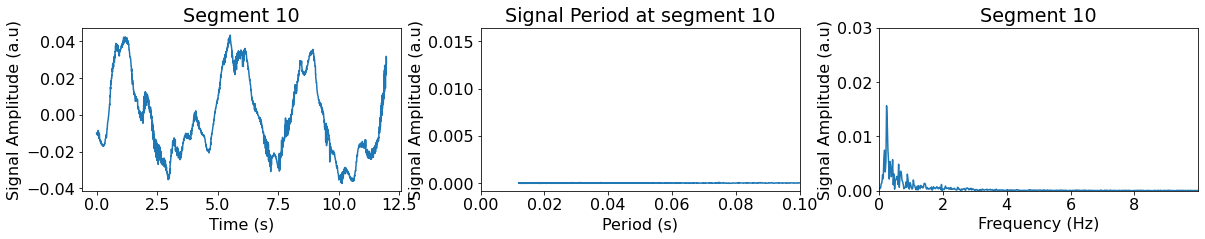

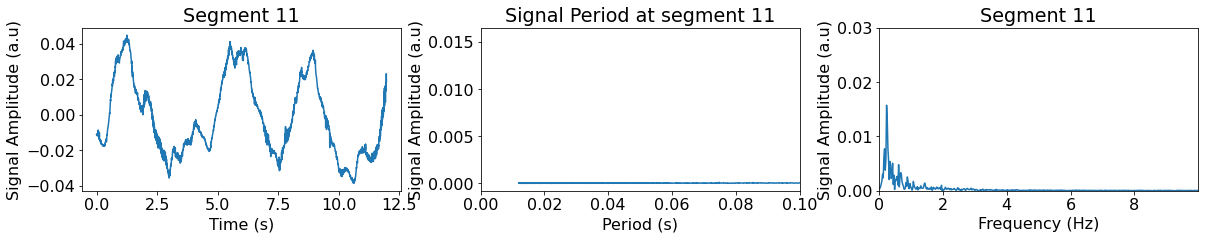

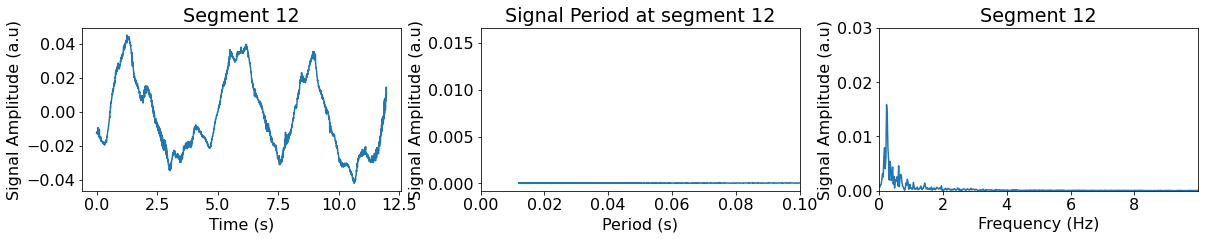

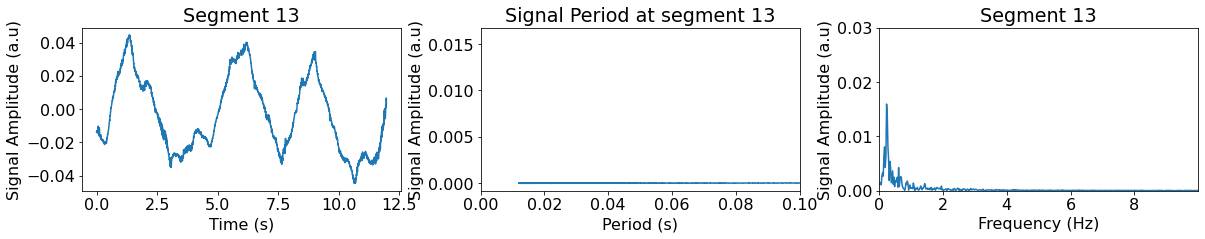

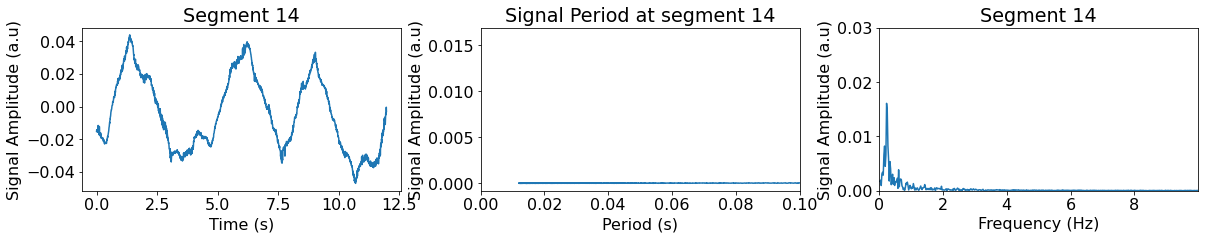

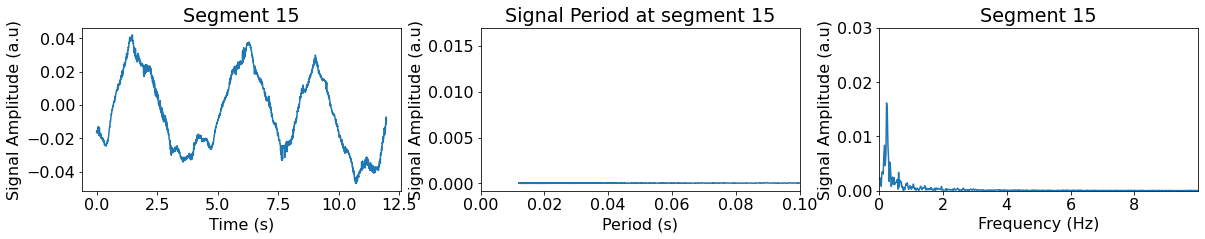

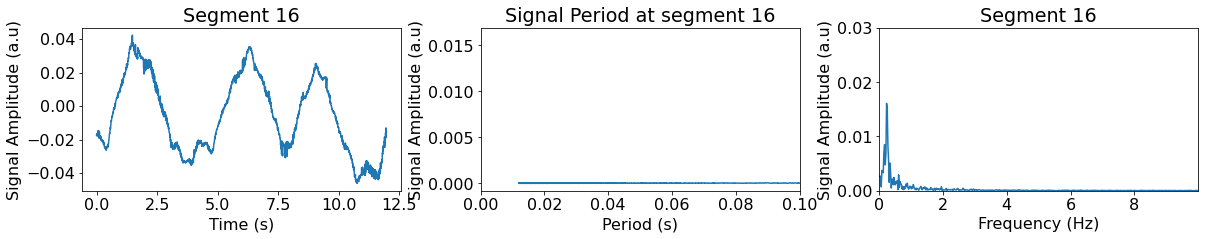

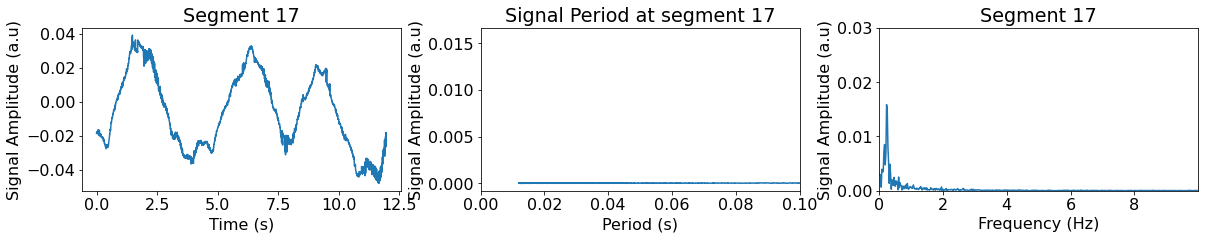

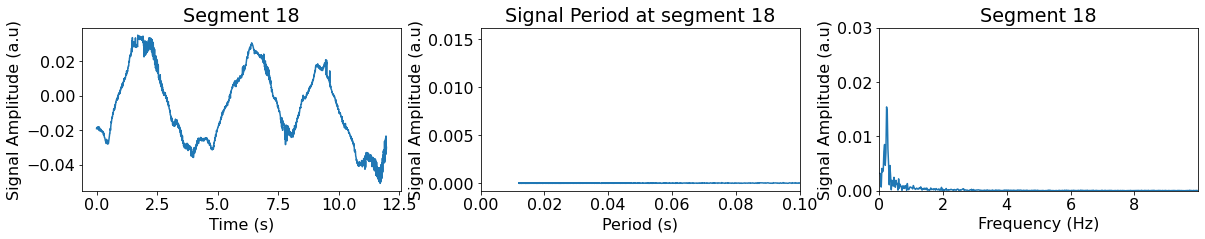

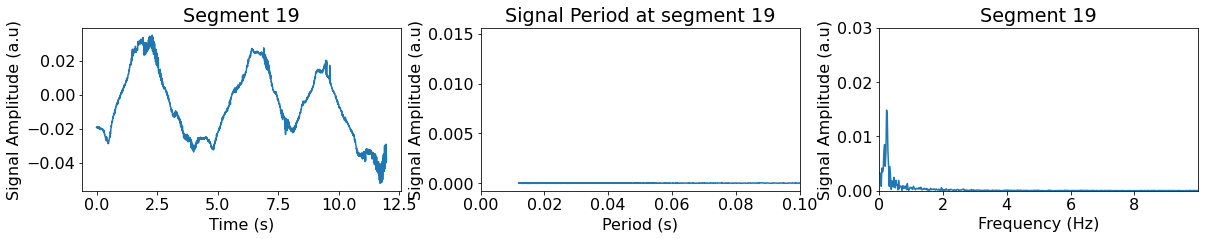

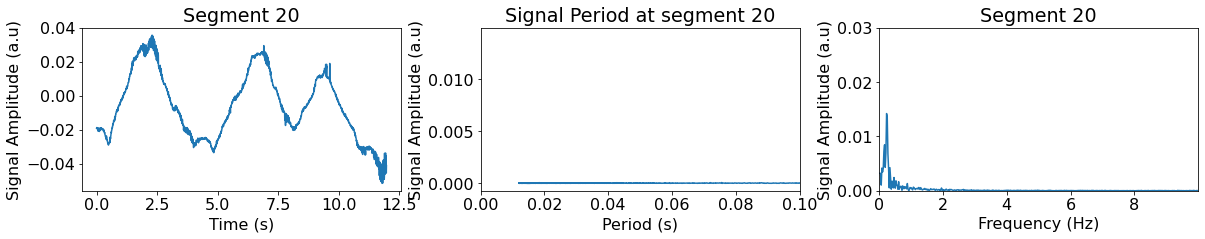

In [20]:
#Now the same but also showing it as image
#to not to have a figure limit
plt.rcParams.update({'figure.max_open_warning': 0})
plt.rcParams.update({'font.size': 16})

#number of sample points: Kts= Kt short
Kts=Kt[:,1696:9604]#[:,0:2500]#[:,79640:130700] all rows(segments) from frame 0 to frame 2500 (about 14 sec)

N=Kts.shape[1]

#hanning
hann=np.hanning(N)

#sample spacing
T=1.0/167.0
x=np.linspace(0.0, N*T, N)

xf=np.linspace(0.0, 1.0//(2.0*T), N//2)
#xf=scipy.fftpack.fftfreq(N,T)

#creates the writer
output_path='/groups/zimmer/shared_projects/DanielMitic/data/ulises_chemotaxis/fourier/all_fourier/'
fourierMap=open(os.path.join(output_path,'2020-07-01_14-41-11_chemotaxisl_worm2_fourierMap.csv'),'w', newline='')
csv_writerfourierMap=csv.writer(fourierMap)

for idx, segment in enumerate(Kts):
    #skip some segments
    #if idx%10!=5:continue
    if idx >20:continue
    
    y=segment
    yf=scipy.fftpack.fft(y)#*hann)
    #define axes
    #y_axis (see that it should start at 1 in yf[1:N//2])
    y_axis=2.0/N * np.abs(yf[1:N//2])
    #x_axis
    x_axis=xf[1:N//2]
    #writer:
    
    #csv_writerfourierMap.writerow(2.0/N * np.abs(yf[1:N//2]))
    
    #define x and y
    x=np.arange(0, y[400:2400].shape[0]/167,1/167)
    y=y[400:2400]
    
    #plotting:
    plotting=1
    if plotting==0:continue
    plt.figure(figsize=(20,3))
    plt.subplot(1,3,1)
    plt.plot(x,y)
    plt.title('Segment '+str(idx))
    plt.xlabel('Time (s)')
    plt.ylabel('Signal Amplitude (a.u)')
    
    #period (ignore)
    plt.subplot(1,3,2)
    plt.plot(1/x_axis, y_axis)
    plt.xlim(0,0.1)
    plt.title('Signal Period at segment '+str(idx))
    plt.xlabel('Period (s)')
    plt.ylabel('Signal Amplitude (a.u)')
    
    plt.subplot(1,3,3)
    plt.plot(x_axis, y_axis)
    #plt.xlim(0,max(xf[1:N//2]))
    plt.xlim(0,10)
    plt.ylim([0, 0.03])
    plt.xticks(np.arange(0, 10, step=2))  
    plt.title('Segment '+str(idx))
    plt.ylabel('Signal Amplitude (a.u)')
    plt.xlabel('Frequency (Hz)')
    
    #plt.subplot(1,3,4)
    #y_img=np.tile(y_axis, (500, 1))
    #plt.imshow(y_img[1:14,0:14], extent=[0,xf[14],100,0], vmin=0, vmax=0.025, aspect=0.0015)
    #plt.yaxis('Off')
    #plt.xlabel('Frequency (Hz)')
    #plt.title('Segment '+str(idx))


    
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.25, hspace=0.25)

#fourierMap.close()

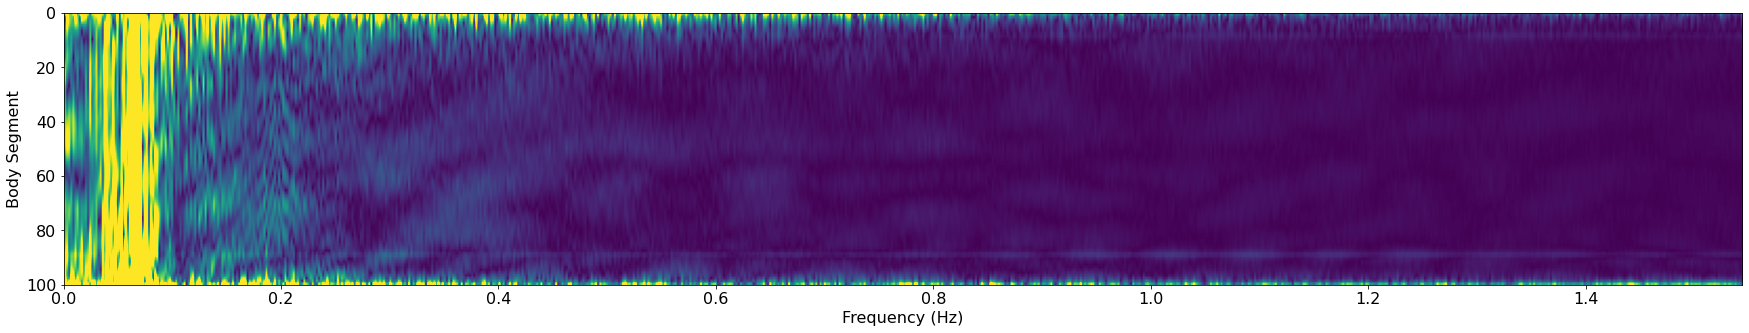

In [ ]:
#fourier transform of the whole recording time of segment 5
body_segment=5
y=K[:,body_segment]
N=len(y) #this might be wrong#number of sample points with Hanning
body_segment=5
y=K[:,body_segment]
N=len(y) #this might be wrong

#sample spacing
T=1.0/167.0
x=np.linspace(0.0, N*T, N)
yf=scipy.fftpack.fft(y)

xf=np.linspace(0.0, 1.0//(2.0*T), N//2)
#xf=scipy.fftpack.fftfreq(N,T)
#define axes
#y_axis (see that it should start at 1 in yf[1:N//2])
y_axis=2.0/N * np.abs(yf[1:N//2])
#x_axis
x_axis=xf[1:N//2]

#with hanning
hann=np.hanning(N)
yf_hann=scipy.fftpack.fft(y*hann)
y_axis_hann=2.0/N * np.abs(yf_hann[1:N//2])


#Trying for the first time this way of subplotting
fig1, f1_axs = plt.subplots(ncols=3, nrows=2, constrained_layout=False, figsize=(20,10))
f1_axs[0,0].plot(y)
f1_axs[0,0].set_title('Signal')
f1_axs[0,0].set_xlabel('Time (frames)')
f1_axs[0,0].set_ylabel('Signal Amplitude (a.u)')

f1_axs[0,1].plot(1/x_axis, y_axis)
f1_axs[0,1].set_title('Signal Period')
f1_axs[0,1].set_xlabel('Period (s)')
f1_axs[0,1].set_ylabel('Signal Amplitude (a.u)')
f1_axs[0,1].set_xlim(0,10)

f1_axs[0,2].plot(x_axis, y_axis)
f1_axs[0,2].set_title('Signal Frequency')
f1_axs[0,2].set_xlabel('Frequency (Hz)')
f1_axs[0,2].set_ylabel('Signal Amplitude (a.u)')
f1_axs[0,2].set_xlim(0,3)

#hanning plotting
f1_axs[1,0].plot(y*hann)
f1_axs[1,0].set_title('Signal with Hanning')
f1_axs[1,0].set_xlabel('Time (frames)')
f1_axs[1,0].set_ylabel('Signal Amplitude (a.u)')

f1_axs[1,1].plot(1/x_axis, y_axis_hann)
f1_axs[1,1].set_title('Signal Period')
f1_axs[1,1].set_xlabel('Period (s)')
f1_axs[1,1].set_ylabel('Signal Amplitude (a.u)')
f1_axs[1,1].set_xlim(0,10)

f1_axs[1,2].plot(x_axis, y_axis_hann)
f1_axs[1,2].set_title('Signal Frequency')
f1_axs[1,2].set_xlabel('Frequency (Hz)')
f1_axs[1,2].set_ylabel('Signal Amplitude (a.u)')
f1_axs[1,2].set_xlim(0,3)

In [ ]:
#this shows the curvature for each segment
#define plot and axis
start=5
stop=600
fps=167
x_axis=np.linspace(start,stop,num=(stop-start)*fps) #array from 5 to 600 with 99365 values(99365=number of seconds *frames per second-->number of frames in recording)

for idx, segment in enumerate(Kt):
    #define which body segments to show
    if idx%50!=5: continue
    fig=plt.figure(figsize=(6,2))
    plt.plot(x_axis,segment[start*fps:stop*fps])
    plt.title('Body Segment '+str(idx))
    plt.xlabel('Time (s)')
    plt.ylabel('K (Curvature)')
    plt.show()
#    break

In [ ]:
#Now the same but also showing it as image
#to not to have a figure limit
plt.rcParams.update({'figure.max_open_warning': 0})
plt.rcParams.update({'font.size': 16})

#number of sample points: Kts= Kt short
Kts=Kt[:,0:2500]#[:,0:2500]#[:,79640:130700]

N=Kts.shape[1]

#hanning
hann=np.hanning(N)

#sample spacing
T=1.0/167.0
x=np.linspace(0.0, N*T, N)

xf=np.linspace(0.0, 1.0//(2.0*T), N//2)
#xf=scipy.fftpack.fftfreq(N,T)

#creates the writer
output_path='/groups/zimmer/shared_projects/DanielMitic/data/ulises_chemotaxis/fourier/all_fourier/'
fourierMap=open(os.path.join(output_path,'2020-07-01_14-41-11_chemotaxisl_worm2_fourierMap.csv'),'w', newline='')
csv_writerfourierMap=csv.writer(fourierMap)

for idx, segment in enumerate(Kts):
    #skip some segments
    #if idx%10!=5:continue
    if idx >20:continue
    
    y=segment
    yf=scipy.fftpack.fft(y)#*hann)
    #define axes
    #y_axis (see that it should start at 1 in yf[1:N//2])
    y_axis=2.0/N * np.abs(yf[1:N//2])
    #x_axis
    x_axis=xf[1:N//2]
    #writer:
    
    #csv_writerfourierMap.writerow(2.0/N * np.abs(yf[1:N//2]))
    
    #define x and y
    x=np.arange(0, y[400:2400].shape[0]/167,1/167)
    y=y[400:2400]
    
    #plotting:
    plotting=1
    if plotting==0:continue
    plt.figure(figsize=(20,3))
    plt.subplot(1,3,1)
    plt.plot(x,y)
    plt.title('Segment '+str(idx))
    plt.xlabel('Time (s)')
    plt.ylabel('Signal Amplitude (a.u)')
    
    #period (ignore)
#     plt.subplot(1,3,2)
#     plt.plot(1/x_axis, y_axis)
#     plt.xlim(0,10)
#     plt.title('Signal Period at segment '+str(idx))
#     plt.xlabel('Period (s)')
#     plt.ylabel('Signal Amplitude (a.u)')
    
    plt.subplot(1,3,2)
    plt.plot(x_axis, y_axis)
    #plt.xlim(0,max(xf[1:N//2]))
    plt.xlim(0,2)
    plt.ylim([0, 0.03])
    plt.xticks(np.arange(0, 2, step=0.5))  
    plt.title('Segment '+str(idx))
    plt.ylabel('Signal Amplitude (a.u)')
    plt.xlabel('Frequency (Hz)')
    
    plt.subplot(1,3,3)
    y_img=np.tile(y_axis, (500, 1))
    plt.imshow(y_img[1:14,0:14], extent=[0,xf[14],100,0], vmin=0, vmax=0.025, aspect=0.0015)
    #plt.yaxis('Off')
    plt.xlabel('Frequency (Hz)')
    plt.title('Segment '+str(idx))


    
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.25, hspace=0.25)

#fourierMap.close()